# GAIA Paraphrase Group Variance Analysis

This notebook measures how much **execution behavior varies within each paraphrase group** (original prompt + paraphrases sharing the same base task) compared with the overall dataset.

Main question: **Does Claude Code produce different execution plans even when the prompts are essentially the same task?**

The notebook reports:

- scalar variance comparison for:
  - `total_steps`
  - `total_tokens`
  - `total_latency_ms`
- interpretable within-group vs overall comparisons for:
  - **tool set**
  - **tool count**
  - **tool sequence**

By default, the analysis uses **successful traces only**. You can switch that off in the config cell.


In [1]:

from pathlib import Path
from collections import Counter
import json
import re

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt


In [2]:

# ============================================================
# Configuration
# ============================================================
DEFAULT_PROJECT_ROOT = Path("/home/tungichen_umass_edu/ekb-claude-pilot")
PROJECT_ROOT = DEFAULT_PROJECT_ROOT if DEFAULT_PROJECT_ROOT.exists() else Path.cwd().resolve()

RESULTS_ROOT = PROJECT_ROOT / "results" / "claude_native"

# Change this to the run folder you want to analyze
RUN_NAME = "gaia_level1_expanded_claude_native_maxturn12"

RUN_ROOT = RESULTS_ROOT / RUN_NAME
OUTPUT_DIR = PROJECT_ROOT / "results" / "analysis" / f"{RUN_NAME}_paraphrase_group_variance"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Main analysis toggle
FILTER_SUCCESS_ONLY = True

# Require at least this many traces in a paraphrase group after filtering
MIN_GROUP_SIZE = 2

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RUN_ROOT:", RUN_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("FILTER_SUCCESS_ONLY:", FILTER_SUCCESS_ONLY)
print("MIN_GROUP_SIZE:", MIN_GROUP_SIZE)


PROJECT_ROOT: /home/tungichen_umass_edu/ekb-claude-pilot
RUN_ROOT: /home/tungichen_umass_edu/ekb-claude-pilot/results/claude_native/gaia_level1_expanded_claude_native_maxturn12
OUTPUT_DIR: /home/tungichen_umass_edu/ekb-claude-pilot/results/analysis/gaia_level1_expanded_claude_native_maxturn12_paraphrase_group_variance
FILTER_SUCCESS_ONLY: True
MIN_GROUP_SIZE: 2


In [3]:

# ============================================================
# Helpers for loading traces
# ============================================================
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def iter_normalized_trace_paths(run_root: Path):
    if not run_root.exists():
        raise FileNotFoundError(f"Trace root does not exist: {run_root}")
    for path in sorted(run_root.glob("*/normalized_trace.json")):
        yield path

def canonical_tool_name(tool):
    if tool is None:
        return "unknown"
    tool = str(tool).strip()
    mapping = {
        "WebSearch": "WebSearch",
        "WebFetch": "WebFetch",
        "Bash": "Bash",
        "Read": "Read",
        "Write": "Write",
        "Edit": "Edit",
        "Grep": "Grep",
        "Glob": "Glob",
        "ToolSearch": "ToolSearch",
        "StructuredOutput": "StructuredOutput",
    }
    return mapping.get(tool, tool)

def extract_steps(trace: dict):
    steps = trace.get("steps", [])
    if not isinstance(steps, list):
        return []
    out = []
    for s in steps:
        if not isinstance(s, dict):
            continue
        out.append({
            "step": s.get("step"),
            "tool": canonical_tool_name(s.get("tool")),
            "status": s.get("status"),
            "latency_ms": s.get("latency_ms"),
        })
    return out

def safe_num(x, default=np.nan):
    try:
        if x is None:
            return default
        return float(x)
    except Exception:
        return default

def base_task_id_from_query_id(query_id: str) -> str:
    return re.sub(r"__para\d+$", "", str(query_id))

def build_trace_record(path: Path):
    trace = load_json(path)
    steps = extract_steps(trace)
    tools_all = [s["tool"] for s in steps]
    tool_counts = Counter(tools_all)

    return {
        "query_id": trace.get("query_id"),
        "base_task_id": base_task_id_from_query_id(trace.get("query_id")),
        "query_text": trace.get("query_text", ""),
        "benchmark": trace.get("benchmark"),
        "split": trace.get("split"),
        "level": trace.get("level"),
        "agent": trace.get("agent"),
        "model_requested": trace.get("model_requested"),
        "effort": trace.get("effort"),

        "total_steps": int(trace.get("total_steps", len(steps) or 0)),
        "total_tool_calls": int(trace.get("total_tool_calls", len(steps) or 0)),
        "total_latency_ms": safe_num(trace.get("total_latency_ms")),
        "total_tokens": safe_num(trace.get("total_tokens")),

        "tool_sequence_all": tools_all,
        "tools_used": sorted(set(tools_all)),

        "success": trace.get("success"),
        "exact_match": trace.get("exact_match"),
        "final_answer_pred": trace.get("final_answer_pred"),
        "ground_truth_answer": trace.get("ground_truth_answer"),
        "normalized_trace_path": str(path),
        "task_dir": str(path.parent),
        "run_name": path.parent.parent.name,
        "task_folder_name": path.parent.name,

        "_tool_counts": dict(tool_counts),
    }


In [4]:

# ============================================================
# Load traces
# ============================================================
trace_paths = list(iter_normalized_trace_paths(RUN_ROOT))
print(f"Found {len(trace_paths)} normalized_trace.json files under {RUN_ROOT}")

trace_records = [build_trace_record(p) for p in trace_paths]
df_all = pd.DataFrame(trace_records)

print(f"Loaded {len(df_all)} normalized traces.")

all_tools = sorted({
    tool
    for record in trace_records
    for tool in record["_tool_counts"].keys()
})

for tool in all_tools:
    col = f"tool_count__{tool}"
    df_all[col] = df_all["_tool_counts"].apply(lambda d: int(d.get(tool, 0)))

df_all = df_all.drop(columns=["_tool_counts"])

for c in ["total_steps", "total_tool_calls", "total_latency_ms", "total_tokens"]:
    df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

df_all["total_steps"] = df_all["total_steps"].fillna(0).astype(int)
df_all["total_tool_calls"] = df_all["total_tool_calls"].fillna(0).astype(int)
df_all["total_latency_ms"] = df_all["total_latency_ms"].fillna(0.0)
df_all["total_tokens"] = df_all["total_tokens"].fillna(0.0)

display(df_all[[
    "query_id", "base_task_id", "success", "exact_match",
    "total_steps", "total_latency_ms", "total_tokens",
    "tools_used", "tool_sequence_all"
]].head(5))


Found 202 normalized_trace.json files under /home/tungichen_umass_edu/ekb-claude-pilot/results/claude_native/gaia_level1_expanded_claude_native_maxturn12
Loaded 202 normalized traces.


,query_id,base_task_id,success,exact_match,total_steps,total_latency_ms,total_tokens,tools_used,tool_sequence_all
0,0383a3ee-47a7-41a4-b493-519bdefe0488,0383a3ee-47a7-41a4-b493-519bdefe0488,True,False,9,83683.0,204013.0,"[StructuredOutput, ToolSearch, WebFetch, WebSe...","[ToolSearch, WebSearch, ToolSearch, WebFetch, ..."
1,0383a3ee-47a7-41a4-b493-519bdefe0488__para1,0383a3ee-47a7-41a4-b493-519bdefe0488,True,True,8,49461.0,179148.0,"[StructuredOutput, ToolSearch, WebFetch, WebSe...","[ToolSearch, WebSearch, ToolSearch, WebFetch, ..."
2,0383a3ee-47a7-41a4-b493-519bdefe0488__para2,0383a3ee-47a7-41a4-b493-519bdefe0488,True,True,11,144579.0,249898.0,"[StructuredOutput, ToolSearch, WebFetch, WebSe...","[ToolSearch, WebSearch, ToolSearch, WebFetch, ..."
3,0383a3ee-47a7-41a4-b493-519bdefe0488__para3,0383a3ee-47a7-41a4-b493-519bdefe0488,True,True,10,71740.0,225716.0,"[StructuredOutput, ToolSearch, WebFetch, WebSe...","[ToolSearch, WebSearch, ToolSearch, WebFetch, ..."
4,11af4e1a-5f45-467d-9aeb-46f4bb0bf034,11af4e1a-5f45-467d-9aeb-46f4bb0bf034,True,True,1,9087.0,35542.0,[StructuredOutput],[StructuredOutput]


In [5]:

# ============================================================
# Accuracy summary + optional SUCCESS-ONLY filtering
# ============================================================
n_total = len(df_all)
n_success = int(df_all["success"].fillna(False).sum())
n_fail = n_total - n_success

acc_all = pd.to_numeric(df_all["exact_match"], errors="coerce")
overall_accuracy = float(acc_all.fillna(False).mean()) if n_total > 0 else np.nan

acc_success = pd.to_numeric(
    df_all.loc[df_all["success"].fillna(False), "exact_match"],
    errors="coerce"
)
success_accuracy = float(acc_success.fillna(False).mean()) if n_success > 0 else np.nan

print(f"Total traces loaded         : {n_total}")
print(f"Successful traces           : {n_success}")
print(f"Failed traces               : {n_fail}")
print(f"Overall exact-match accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Success-only accuracy       : {success_accuracy:.4f} ({success_accuracy*100:.2f}%)")

if FILTER_SUCCESS_ONLY:
    df = df_all.loc[df_all["success"].fillna(False)].copy().reset_index(drop=True)
else:
    df = df_all.copy().reset_index(drop=True)

print(f"Filtered to {len(df)} traces for paraphrase-group variance analysis.")
display(df[[
    "query_id", "base_task_id", "success", "exact_match",
    "total_steps", "total_latency_ms", "total_tokens"
]].head(5))


Total traces loaded         : 202
Successful traces           : 163
Failed traces               : 39
Overall exact-match accuracy: 0.6980 (69.80%)
Success-only accuracy       : 0.8650 (86.50%)
Filtered to 163 traces for paraphrase-group variance analysis.


,query_id,base_task_id,success,exact_match,total_steps,total_latency_ms,total_tokens
0,0383a3ee-47a7-41a4-b493-519bdefe0488,0383a3ee-47a7-41a4-b493-519bdefe0488,True,False,9,83683.0,204013.0
1,0383a3ee-47a7-41a4-b493-519bdefe0488__para1,0383a3ee-47a7-41a4-b493-519bdefe0488,True,True,8,49461.0,179148.0
2,0383a3ee-47a7-41a4-b493-519bdefe0488__para2,0383a3ee-47a7-41a4-b493-519bdefe0488,True,True,11,144579.0,249898.0
3,0383a3ee-47a7-41a4-b493-519bdefe0488__para3,0383a3ee-47a7-41a4-b493-519bdefe0488,True,True,10,71740.0,225716.0
4,11af4e1a-5f45-467d-9aeb-46f4bb0bf034,11af4e1a-5f45-467d-9aeb-46f4bb0bf034,True,True,1,9087.0,35542.0


In [6]:

# ============================================================
# Paraphrase-group summary and eligibility
# ============================================================
group_sizes_all = (
    df.groupby("base_task_id", as_index=False)
      .agg(
          n_traces=("query_id", "count"),
          n_exact_match_true=("exact_match", lambda s: int(pd.to_numeric(s, errors="coerce").fillna(False).sum())),
      )
      .sort_values("n_traces", ascending=False)
      .reset_index(drop=True)
)

eligible_group_ids = group_sizes_all.loc[group_sizes_all["n_traces"] >= MIN_GROUP_SIZE, "base_task_id"].tolist()
dfg = df[df["base_task_id"].isin(eligible_group_ids)].copy().reset_index(drop=True)

print(f"Total groups after filtering  : {df['base_task_id'].nunique()}")
print(f"Eligible groups (>= {MIN_GROUP_SIZE}) : {len(eligible_group_ids)}")
print(f"Eligible traces retained      : {len(dfg)}")

display(group_sizes_all.head(10))
group_sizes_all.to_csv(OUTPUT_DIR / "paraphrase_group_sizes.csv", index=False)


Total groups after filtering  : 46
Eligible groups (>= 2) : 44
Eligible traces retained      : 161


,base_task_id,n_traces,n_exact_match_true
0,0383a3ee-47a7-41a4-b493-519bdefe0488,4,3
1,11af4e1a-5f45-467d-9aeb-46f4bb0bf034,4,4
2,23dd907f-1261-4488-b21c-e9185af91d5e,4,3
3,27d5d136-8563-469e-92bf-fd103c28b57c,4,4
4,305ac316-eef6-4446-960a-92d80d542f82,4,4
5,3cef3a44-215e-4aed-8e3b-b1e3f08063b7,4,4
6,4fc2f1ae-8625-45b5-ab34-ad4433bc21f8,4,4
7,3f57289b-8c60-48be-bd80-01f8099ca449,4,3
8,42576abe-0deb-4869-8c63-225c2d75a95a,4,4
9,46719c30-f4c3-4cad-be07-d5cb21eee6bb,4,0


## A. Scalar execution variance within paraphrase groups vs overall

For scalar features, we compare:

- **overall variance** across all retained traces
- **pooled within-group variance** across paraphrase groups

A ratio below 1 means paraphrases of the same base task vary less than the dataset as a whole.


In [7]:

# ============================================================
# Scalar variance: within-group vs overall
# ============================================================
SCALAR_COLS = ["total_steps", "total_tokens", "total_latency_ms"]

def pooled_within_group_variance(df_in, value_col, group_col="base_task_id"):
    num = 0.0
    den = 0
    group_rows = []

    for gid, sub in df_in.groupby(group_col):
        vals = pd.to_numeric(sub[value_col], errors="coerce").dropna().to_numpy(dtype=float)
        n = len(vals)
        if n < 2:
            continue
        var_g = float(np.var(vals, ddof=1))
        num += (n - 1) * var_g
        den += (n - 1)
        group_rows.append({
            "base_task_id": gid,
            "n": n,
            "variance": var_g,
            "mean": float(np.mean(vals)),
        })

    pooled = num / den if den > 0 else np.nan
    return pooled, pd.DataFrame(group_rows)

scalar_rows = []
scalar_group_tables = {}

for col in SCALAR_COLS:
    vals = pd.to_numeric(dfg[col], errors="coerce").dropna().to_numpy(dtype=float)
    overall_var = float(np.var(vals, ddof=1)) if len(vals) >= 2 else np.nan
    within_var, df_group_var = pooled_within_group_variance(dfg, col, group_col="base_task_id")
    ratio = (within_var / overall_var) if (pd.notna(within_var) and pd.notna(overall_var) and overall_var > 0) else np.nan

    scalar_rows.append({
        "feature": col,
        "overall_variance": overall_var,
        "within_group_variance": within_var,
        "within_over_overall_ratio": ratio,
    })
    scalar_group_tables[col] = df_group_var

df_scalar_variance = pd.DataFrame(scalar_rows).sort_values("within_over_overall_ratio").reset_index(drop=True)
display(df_scalar_variance)

df_scalar_variance.to_csv(OUTPUT_DIR / "scalar_within_group_variance_summary.csv", index=False)
for col, df_group_var in scalar_group_tables.items():
    df_group_var.to_csv(OUTPUT_DIR / f"scalar_group_variance_{col}.csv", index=False)


,feature,overall_variance,within_group_variance,within_over_overall_ratio
0,total_tokens,5.295966e+09,1.219834e+09,0.230333
1,total_steps,4.541398e+01,1.144872e+01,0.252097
2,total_latency_ms,1.242716e+09,7.406002e+08,0.595953


## B. Interpretable within-group variability for tool set, tool count, and tool sequence

For structured execution outputs, variance is less intuitive than for scalars.  
So this notebook uses more interpretable disagreement metrics:

### Tool set
- **pairwise exact tool-set match rate** within paraphrase groups vs overall
- **average number of distinct tool sets per group**

### Tool count
- **pairwise exact count-profile match rate**
- **pairwise mean L1 distance** (average absolute difference in tool-call counts)
- **average number of distinct count profiles per group**

### Tool sequence
- **pairwise exact sequence match rate**
- **pairwise normalized Levenshtein distance**
- **average number of distinct sequences per group**

For match rates: higher is more stable.  
For distances / number of distinct profiles: lower is more stable.


In [8]:

# ============================================================
# Structured-profile helpers
# ============================================================
tool_count_cols = sorted([c for c in dfg.columns if c.startswith("tool_count__")])

def normalized_levenshtein_distance(seq1, seq2):
    m, n = len(seq1), len(seq2)
    if max(m, n) == 0:
        return 0.0
    dp = np.zeros((m + 1, n + 1), dtype=np.int32)
    for i in range(m + 1):
        dp[i, 0] = i
    for j in range(n + 1):
        dp[0, j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + cost,
            )
    dist = int(dp[m, n])
    return float(dist / max(m, n))

def toolset_repr(row):
    return tuple(sorted(set(row["tools_used"])))

def toolcount_repr(row, cols):
    return tuple(int(row[c]) for c in cols)

def sequence_repr(row):
    return tuple(row["tool_sequence_all"])

def pairwise_values_from_items(items, fn):
    vals = []
    n = len(items)
    for i in range(n):
        for j in range(i + 1, n):
            vals.append(fn(items[i], items[j]))
    return vals

def exact_match_rate(items):
    vals = pairwise_values_from_items(items, lambda a, b: 1.0 if a == b else 0.0)
    return float(np.mean(vals)) if len(vals) > 0 else np.nan

def mean_l1_distance(vectors):
    vals = pairwise_values_from_items(vectors, lambda a, b: float(np.sum(np.abs(np.asarray(a) - np.asarray(b)))))
    return float(np.mean(vals)) if len(vals) > 0 else np.nan

def mean_norm_lev_distance(seqs):
    vals = pairwise_values_from_items(seqs, normalized_levenshtein_distance)
    return float(np.mean(vals)) if len(vals) > 0 else np.nan

def overall_pairwise_metric(items, fn):
    vals = pairwise_values_from_items(items, fn)
    return float(np.mean(vals)) if len(vals) > 0 else np.nan


In [9]:

# ============================================================
# Build representations once
# ============================================================
dfg = dfg.copy()
dfg["toolset_repr"] = dfg.apply(toolset_repr, axis=1)
dfg["toolcount_repr"] = dfg.apply(lambda row: toolcount_repr(row, tool_count_cols), axis=1)
dfg["sequence_repr"] = dfg.apply(sequence_repr, axis=1)

display(dfg[[
    "query_id", "base_task_id", "toolset_repr", "toolcount_repr", "sequence_repr"
]].head(3))


,query_id,base_task_id,toolset_repr,toolcount_repr,sequence_repr
0,0383a3ee-47a7-41a4-b493-519bdefe0488,0383a3ee-47a7-41a4-b493-519bdefe0488,"(StructuredOutput, ToolSearch, WebFetch, WebSe...","(0, 0, 0, 1, 2, 4, 2)","(ToolSearch, WebSearch, ToolSearch, WebFetch, ..."
1,0383a3ee-47a7-41a4-b493-519bdefe0488__para1,0383a3ee-47a7-41a4-b493-519bdefe0488,"(StructuredOutput, ToolSearch, WebFetch, WebSe...","(0, 0, 0, 1, 2, 3, 2)","(ToolSearch, WebSearch, ToolSearch, WebFetch, ..."
2,0383a3ee-47a7-41a4-b493-519bdefe0488__para2,0383a3ee-47a7-41a4-b493-519bdefe0488,"(StructuredOutput, ToolSearch, WebFetch, WebSe...","(0, 0, 0, 2, 2, 4, 3)","(ToolSearch, WebSearch, ToolSearch, WebFetch, ..."


In [10]:

# ============================================================
# Tool set stability
# ============================================================
group_toolset_rows = []
for gid, sub in dfg.groupby("base_task_id"):
    items = sub["toolset_repr"].tolist()
    if len(items) < 2:
        continue
    group_toolset_rows.append({
        "base_task_id": gid,
        "n": len(items),
        "pairwise_exact_match_rate": exact_match_rate(items),
        "n_distinct_toolsets": len(set(items)),
    })

df_toolset_group = pd.DataFrame(group_toolset_rows)

overall_toolset_exact_match_rate = overall_pairwise_metric(
    dfg["toolset_repr"].tolist(),
    lambda a, b: 1.0 if a == b else 0.0,
)

toolset_summary = pd.DataFrame([{
    "metric": "tool_set",
    "within_group_exact_match_rate_mean": float(df_toolset_group["pairwise_exact_match_rate"].mean()),
    "overall_exact_match_rate": overall_toolset_exact_match_rate,
    "within_minus_overall_match_rate": float(df_toolset_group["pairwise_exact_match_rate"].mean()) - overall_toolset_exact_match_rate,
    "avg_distinct_profiles_per_group": float(df_toolset_group["n_distinct_toolsets"].mean()),
    "median_distinct_profiles_per_group": float(df_toolset_group["n_distinct_toolsets"].median()),
}])

display(df_toolset_group.sort_values(["pairwise_exact_match_rate", "n_distinct_toolsets"]).reset_index(drop=True).head(10))
display(toolset_summary)

df_toolset_group.to_csv(OUTPUT_DIR / "toolset_group_stability.csv", index=False)
toolset_summary.to_csv(OUTPUT_DIR / "toolset_summary.csv", index=False)


,base_task_id,n,pairwise_exact_match_rate,n_distinct_toolsets
0,1f975693-876d-457b-a649-393859e79bf3,2,0.000000,2
1,7673d772-ef80-4f0f-a602-1bf4485c9b43,2,0.000000,2
2,7d4a7d1d-cac6-44a8-96e8-ea9584a70825,3,0.000000,3
3,a3fbeb63-0e8c-4a11-bff6-0e3b484c3e9c,3,0.000000,3
4,c365c1c7-a3db-4d5e-a9a1-66f56eae7865,4,0.000000,4
5,5cfb274c-0207-4aa7-9575-6ac0bd95d9b2,4,0.166667,3
6,23dd907f-1261-4488-b21c-e9185af91d5e,4,0.333333,2
7,7bd855d8-463d-4ed5-93ca-5fe35145f733,3,0.333333,2
8,9318445f-fe6a-4e1b-acbf-c68228c9906a,3,0.333333,2
9,cffe0e32-c9a6-4c52-9877-78ceb4aaa9fb,4,0.333333,2


,metric,within_group_exact_match_rate_mean,overall_exact_match_rate,within_minus_overall_match_rate,avg_distinct_profiles_per_group,median_distinct_profiles_per_group
0,tool_set,0.742424,0.209006,0.533418,1.454545,1.0


In [11]:

# ============================================================
# Tool count stability
# ============================================================
group_toolcount_rows = []
for gid, sub in dfg.groupby("base_task_id"):
    items = sub["toolcount_repr"].tolist()
    if len(items) < 2:
        continue
    group_toolcount_rows.append({
        "base_task_id": gid,
        "n": len(items),
        "pairwise_exact_match_rate": exact_match_rate(items),
        "pairwise_mean_l1_distance": mean_l1_distance(items),
        "n_distinct_count_profiles": len(set(items)),
    })

df_toolcount_group = pd.DataFrame(group_toolcount_rows)

overall_toolcount_exact_match_rate = overall_pairwise_metric(
    dfg["toolcount_repr"].tolist(),
    lambda a, b: 1.0 if a == b else 0.0,
)
overall_toolcount_mean_l1 = overall_pairwise_metric(
    dfg["toolcount_repr"].tolist(),
    lambda a, b: float(np.sum(np.abs(np.asarray(a) - np.asarray(b)))),
)

toolcount_summary = pd.DataFrame([{
    "metric": "tool_count",
    "within_group_exact_match_rate_mean": float(df_toolcount_group["pairwise_exact_match_rate"].mean()),
    "overall_exact_match_rate": overall_toolcount_exact_match_rate,
    "within_group_mean_l1_distance": float(df_toolcount_group["pairwise_mean_l1_distance"].mean()),
    "overall_mean_l1_distance": overall_toolcount_mean_l1,
    "distance_ratio_within_over_overall": float(df_toolcount_group["pairwise_mean_l1_distance"].mean() / overall_toolcount_mean_l1) if pd.notna(overall_toolcount_mean_l1) and overall_toolcount_mean_l1 > 0 else np.nan,
    "avg_distinct_profiles_per_group": float(df_toolcount_group["n_distinct_count_profiles"].mean()),
    "median_distinct_profiles_per_group": float(df_toolcount_group["n_distinct_count_profiles"].median()),
}])

display(df_toolcount_group.sort_values(["pairwise_mean_l1_distance", "n_distinct_count_profiles"]).reset_index(drop=True).head(10))
display(toolcount_summary)

df_toolcount_group.to_csv(OUTPUT_DIR / "toolcount_group_stability.csv", index=False)
toolcount_summary.to_csv(OUTPUT_DIR / "toolcount_summary.csv", index=False)


,base_task_id,n,pairwise_exact_match_rate,pairwise_mean_l1_distance,n_distinct_count_profiles
0,11af4e1a-5f45-467d-9aeb-46f4bb0bf034,4,1.0,0.0,1
1,27d5d136-8563-469e-92bf-fd103c28b57c,4,1.0,0.0,1
2,305ac316-eef6-4446-960a-92d80d542f82,4,1.0,0.0,1
3,3cef3a44-215e-4aed-8e3b-b1e3f08063b7,4,1.0,0.0,1
4,42576abe-0deb-4869-8c63-225c2d75a95a,4,1.0,0.0,1
5,4b650a35-8529-4695-89ed-8dc7a500a498,4,1.0,0.0,1
6,4fc2f1ae-8625-45b5-ab34-ad4433bc21f8,4,1.0,0.0,1
7,50ad0280-0819-4bd9-b275-5de32d3b5bcb,4,1.0,0.0,1
8,5188369a-3bbe-43d8-8b94-11558f909a08,3,1.0,0.0,1
9,6f37996b-2ac7-44b0-8e68-6d28256631b4,4,1.0,0.0,1


,metric,within_group_exact_match_rate_mean,overall_exact_match_rate,within_group_mean_l1_distance,overall_mean_l1_distance,distance_ratio_within_over_overall,avg_distinct_profiles_per_group,median_distinct_profiles_per_group
0,tool_count,0.386364,0.071118,4.106061,9.218012,0.445439,2.386364,3.0


In [12]:

# ============================================================
# Tool sequence stability
# ============================================================
group_sequence_rows = []
for gid, sub in dfg.groupby("base_task_id"):
    items = sub["sequence_repr"].tolist()
    if len(items) < 2:
        continue
    group_sequence_rows.append({
        "base_task_id": gid,
        "n": len(items),
        "pairwise_exact_match_rate": exact_match_rate(items),
        "pairwise_mean_normalized_levenshtein_distance": mean_norm_lev_distance(items),
        "n_distinct_sequences": len(set(items)),
    })

df_sequence_group = pd.DataFrame(group_sequence_rows)

overall_sequence_exact_match_rate = overall_pairwise_metric(
    dfg["sequence_repr"].tolist(),
    lambda a, b: 1.0 if a == b else 0.0,
)
overall_sequence_mean_levdist = overall_pairwise_metric(
    dfg["sequence_repr"].tolist(),
    normalized_levenshtein_distance,
)

sequence_summary = pd.DataFrame([{
    "metric": "tool_sequence",
    "within_group_exact_match_rate_mean": float(df_sequence_group["pairwise_exact_match_rate"].mean()),
    "overall_exact_match_rate": overall_sequence_exact_match_rate,
    "within_group_mean_normalized_levenshtein_distance": float(df_sequence_group["pairwise_mean_normalized_levenshtein_distance"].mean()),
    "overall_mean_normalized_levenshtein_distance": overall_sequence_mean_levdist,
    "distance_ratio_within_over_overall": float(df_sequence_group["pairwise_mean_normalized_levenshtein_distance"].mean() / overall_sequence_mean_levdist) if pd.notna(overall_sequence_mean_levdist) and overall_sequence_mean_levdist > 0 else np.nan,
    "avg_distinct_profiles_per_group": float(df_sequence_group["n_distinct_sequences"].mean()),
    "median_distinct_profiles_per_group": float(df_sequence_group["n_distinct_sequences"].median()),
}])

display(df_sequence_group.sort_values(["pairwise_mean_normalized_levenshtein_distance", "n_distinct_sequences"]).reset_index(drop=True).head(10))
display(sequence_summary)

df_sequence_group.to_csv(OUTPUT_DIR / "sequence_group_stability.csv", index=False)
sequence_summary.to_csv(OUTPUT_DIR / "sequence_summary.csv", index=False)


,base_task_id,n,pairwise_exact_match_rate,pairwise_mean_normalized_levenshtein_distance,n_distinct_sequences
0,11af4e1a-5f45-467d-9aeb-46f4bb0bf034,4,1.0,0.0,1
1,27d5d136-8563-469e-92bf-fd103c28b57c,4,1.0,0.0,1
2,305ac316-eef6-4446-960a-92d80d542f82,4,1.0,0.0,1
3,3cef3a44-215e-4aed-8e3b-b1e3f08063b7,4,1.0,0.0,1
4,42576abe-0deb-4869-8c63-225c2d75a95a,4,1.0,0.0,1
5,4b650a35-8529-4695-89ed-8dc7a500a498,4,1.0,0.0,1
6,4fc2f1ae-8625-45b5-ab34-ad4433bc21f8,4,1.0,0.0,1
7,50ad0280-0819-4bd9-b275-5de32d3b5bcb,4,1.0,0.0,1
8,5188369a-3bbe-43d8-8b94-11558f909a08,3,1.0,0.0,1
9,6f37996b-2ac7-44b0-8e68-6d28256631b4,4,1.0,0.0,1


,metric,within_group_exact_match_rate_mean,overall_exact_match_rate,within_group_mean_normalized_levenshtein_distance,overall_mean_normalized_levenshtein_distance,distance_ratio_within_over_overall,avg_distinct_profiles_per_group,median_distinct_profiles_per_group
0,tool_sequence,0.378788,0.070109,0.271,0.683845,0.396288,2.409091,3.0


In [13]:

# ============================================================
# Final combined summary
# ============================================================
df_structured_summary = pd.concat(
    [toolset_summary, toolcount_summary, sequence_summary],
    ignore_index=True,
    sort=False,
)

print("Scalar within-group variance summary")
display(df_scalar_variance)

print("Structured-profile stability summary")
display(df_structured_summary)

df_structured_summary.to_csv(OUTPUT_DIR / "structured_group_stability_summary.csv", index=False)


Scalar within-group variance summary


,feature,overall_variance,within_group_variance,within_over_overall_ratio
0,total_tokens,5.295966e+09,1.219834e+09,0.230333
1,total_steps,4.541398e+01,1.144872e+01,0.252097
2,total_latency_ms,1.242716e+09,7.406002e+08,0.595953


Structured-profile stability summary


,metric,within_group_exact_match_rate_mean,overall_exact_match_rate,within_minus_overall_match_rate,avg_distinct_profiles_per_group,median_distinct_profiles_per_group,within_group_mean_l1_distance,overall_mean_l1_distance,distance_ratio_within_over_overall,within_group_mean_normalized_levenshtein_distance,overall_mean_normalized_levenshtein_distance
0,tool_set,0.742424,0.209006,0.533418,1.454545,1.0,NaN,NaN,NaN,NaN,NaN
1,tool_count,0.386364,0.071118,NaN,2.386364,3.0,4.106061,9.218012,0.445439,NaN,NaN
2,tool_sequence,0.378788,0.070109,NaN,2.409091,3.0,NaN,NaN,0.396288,0.271,0.683845


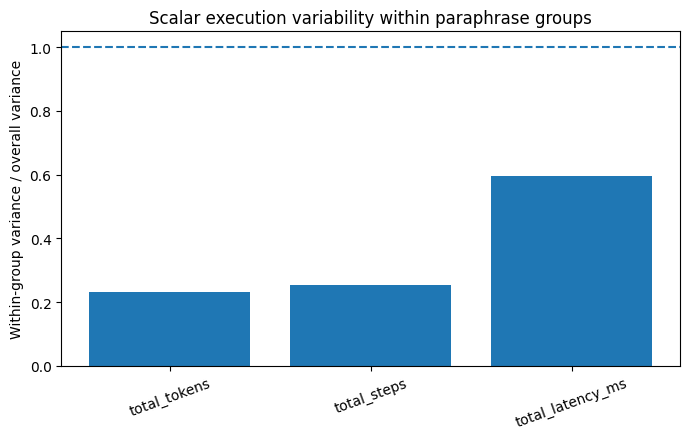

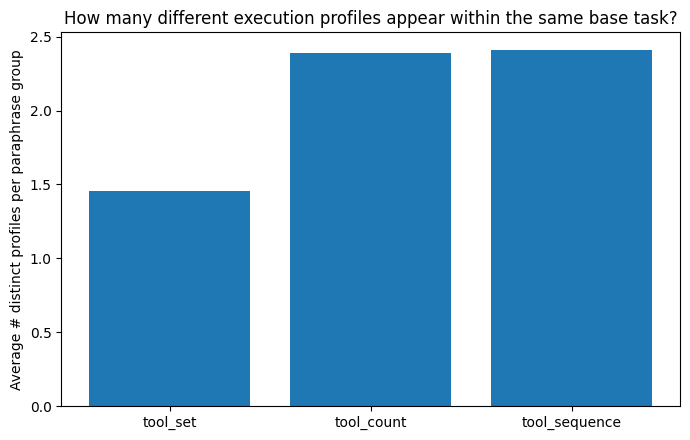

In [14]:

# ============================================================
# Optional: quick visualizations
# ============================================================

# Scalar variance ratio
plt.figure(figsize=(7, 4.5))
plt.bar(df_scalar_variance["feature"], df_scalar_variance["within_over_overall_ratio"])
plt.axhline(1.0, linestyle="--")
plt.ylabel("Within-group variance / overall variance")
plt.title("Scalar execution variability within paraphrase groups")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Average number of distinct execution profiles per group
viz_rows = [
    ("tool_set", float(df_toolset_group["n_distinct_toolsets"].mean())),
    ("tool_count", float(df_toolcount_group["n_distinct_count_profiles"].mean())),
    ("tool_sequence", float(df_sequence_group["n_distinct_sequences"].mean())),
]
df_viz = pd.DataFrame(viz_rows, columns=["representation", "avg_distinct_profiles_per_group"])

plt.figure(figsize=(7, 4.5))
plt.bar(df_viz["representation"], df_viz["avg_distinct_profiles_per_group"])
plt.ylabel("Average # distinct profiles per paraphrase group")
plt.title("How many different execution profiles appear within the same base task?")
plt.tight_layout()
plt.show()
